In [58]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
from apps.onpe.schemas import ConsultaElectoral, Eleccion
from typing import Literal
from apps.onpe.client import get_resultados_onpe, cookies, headers
from apps.onpe.enums import UbigeoNivel1, UbigeoNivel2, UbigeoNivel3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from concurrent.futures import ThreadPoolExecutor
import requests

In [60]:
count = 0

def procesar_un_ubigeo(ubigeo3):
    global count
    print(f"{count=}")
    count = count + 1
    # Aquí mueves TODO el contenido que tenías dentro de tu loop actual
    # incluyendo los try/except y las peticiones get_resultados_onpe
    try:
        consulta_electoral = ConsultaElectoral(eleccion=Eleccion.PRESIDENCIAL, ubigeo_3=ubigeo3)

        data_detalle = get_resultados_onpe(consulta_electoral, mode='detalle')['data']
        data_participacion = get_resultados_onpe(consulta_electoral, mode="participacion")['data']

        actas_contabilizadas_porcentaje = data_participacion['porcentajeAsistentes'] + data_participacion['porcentajeAusentes']

        if actas_contabilizadas_porcentaje <= 10:
            print(f"Ubigeo {ubigeo3.name}: No se han contabilizado actas aún. Proyectando resultados...")
            total_actas = data_participacion['totalElectoresHabiles']

            # Calcular segun ubigeo nivel 2
            ubigeo_nivel_2 = ubigeo3.nivel2
            consulta_ubigeo_nivel_2 = ConsultaElectoral(eleccion=Eleccion.PRESIDENCIAL, ubigeo_2=ubigeo_nivel_2)
            nivel_2_participacion = get_resultados_onpe(consulta_ubigeo_nivel_2, mode='participacion')['data']
            nivel_2_detalle = get_resultados_onpe(consulta_ubigeo_nivel_2, mode='detalle')['data']

            nivel_2_actas_porcentaje = nivel_2_participacion['porcentajeAsistentes'] + nivel_2_participacion['porcentajeAusentes']

            if nivel_2_actas_porcentaje <= 10:
                print(f"Ubigeo {ubigeo_nivel_2.name}: No se han contabilizado actas aún en el nivel2. Proyectando resultados...")
                # Calcular segun ubigeo nivel 1
                ubigeo_nivel_1 = ubigeo_nivel_2.nivel1
                consulta_ubigeo_nivel_1 = ConsultaElectoral(eleccion=Eleccion.PRESIDENCIAL, ubigeo=ubigeo_nivel_1)
                nivel_1_participacion = get_resultados_onpe(consulta_ubigeo_nivel_1, mode='participacion')['data']
                nivel_1_detalle = get_resultados_onpe(consulta_ubigeo_nivel_1, mode='detalle')['data']

                nivel_1_actas_porcentaje = nivel_1_participacion['porcentajeAsistentes'] + nivel_1_participacion['porcentajeAusentes']
                nivel_1_jp_votos = next(d['totalVotosValidos'] for d in nivel_1_detalle if d['nombreAgrupacionPolitica'] == 'JUNTOS POR EL PERÚ')
                nivel_1_porky_votos = next(d['totalVotosValidos'] for d in nivel_1_detalle if d['nombreAgrupacionPolitica'] == 'RENOVACIÓN POPULAR')

                nivel_1_jp_votos_proyectados = nivel_1_jp_votos / nivel_1_actas_porcentaje * 100
                nivel_1_porky_votos_proyectados = nivel_1_porky_votos / nivel_1_actas_porcentaje * 100

                total_actas_nivel_1 = nivel_1_participacion['totalElectoresHabiles']

                nivel_2_jp_votos_proyectados = nivel_1_jp_votos_proyectados / total_actas_nivel_1 * total_actas
                nivel_2_porky_votos_proyectados = nivel_1_porky_votos_proyectados / total_actas_nivel_1 * total_actas

                jp_data = {
                    'nombreAgrupacionPolitica': 'JUNTOS POR EL PERÚ',
                    'ubigeo1': ubigeo_nivel_1.name,
                    'ubigeo2': ubigeo_nivel_2.name,
                    'ubigeo3': ubigeo3.name,
                    'actualVotosValidos': nivel_2_jp_votos_proyectados,
                    'proyeccionVotosValidos': nivel_2_jp_votos_proyectados
                }

                porky_data = {
                    'nombreAgrupacionPolitica': 'RENOVACIÓN POPULAR',
                    'ubigeo1': ubigeo_nivel_1.name,
                    'ubigeo2': ubigeo_nivel_2.name,
                    'ubigeo3': ubigeo3.name,
                    'actualVotosValidos': nivel_2_porky_votos_proyectados,
                    'proyeccionVotosValidos': nivel_2_porky_votos_proyectados
                }
                return [jp_data, porky_data]
            
            nivel_2_jp_votos = next(d['totalVotosValidos'] for d in nivel_2_detalle if d['nombreAgrupacionPolitica'] == 'JUNTOS POR EL PERÚ')
            nivel_2_porky_votos = next(d['totalVotosValidos'] for d in nivel_2_detalle if d['nombreAgrupacionPolitica'] == 'RENOVACIÓN POPULAR')

            nivel_2_jp_votos_proyectados = nivel_2_jp_votos / nivel_2_actas_porcentaje * 100
            nivel_2_porky_votos_proyectados = nivel_2_porky_votos / nivel_2_actas_porcentaje * 100

            total_actas_nivel_2 = nivel_2_participacion['totalElectoresHabiles']

            nivel_2_jp_votos_proyectados = nivel_2_jp_votos_proyectados / total_actas_nivel_2 * total_actas
            nivel_2_porky_votos_proyectados = nivel_2_porky_votos_proyectados / total_actas_nivel_2 * total_actas

            jp_data = {
                'nombreAgrupacionPolitica': 'JUNTOS POR EL PERÚ',
                'ubigeo1': ubigeo_nivel_2.nivel1.name,
                'ubigeo2': ubigeo_nivel_2.name,
                'ubigeo3': ubigeo3.name,
                'actualVotosValidos': nivel_2_jp_votos_proyectados,
                'proyeccionVotosValidos': nivel_2_jp_votos_proyectados
            }

            porky_data = {
                'nombreAgrupacionPolitica': 'RENOVACIÓN POPULAR',
                'ubigeo1': ubigeo_nivel_2.nivel1.name,
                'ubigeo2': ubigeo_nivel_2.name,
                'ubigeo3': ubigeo3.name,
                'actualVotosValidos': nivel_2_porky_votos_proyectados,
                'proyeccionVotosValidos': nivel_2_porky_votos_proyectados
            }
            return [jp_data, porky_data]

        return [{
            'nombreAgrupacionPolitica': data['nombreAgrupacionPolitica'],
            'ubigeo1': consulta_electoral.ubigeo.name,
            'ubigeo2': consulta_electoral.ubigeo_2.name,
            'ubigeo3': consulta_electoral.ubigeo_3.name,
            'actualVotosValidos': data['totalVotosValidos'],
            'proyeccionVotosValidos': data['totalVotosValidos'] / actas_contabilizadas_porcentaje * 100
        } for data in data_detalle]
    except Exception as e:
        print(f"Error en {ubigeo3.name}: {e}")
        return []

In [61]:
def plot_proyeccion():
    count = 0
    all_data = []
    with ThreadPoolExecutor(max_workers=20) as executor:
        # Mapeamos la función a la lista de ubigeos
        resultados = list(executor.map(procesar_un_ubigeo, UbigeoNivel3))

    all_data = [item for sublist in resultados for item in sublist]
    df_proyeccion = pd.DataFrame(all_data)
    df_proyeccion['proyeccionVotosValidos']= df_proyeccion['proyeccionVotosValidos'].astype(int)
    df_proyeccion['actualVotosValidos']= df_proyeccion['actualVotosValidos'].astype(int)

    df_final = df_proyeccion.groupby('nombreAgrupacionPolitica').sum(numeric_only=True).sort_values('proyeccionVotosValidos', ascending=False)
    # df_final.drop(index=['VOTOS EN BLANCO', 'VOTOS NULOS'], inplace=True)
    df_final['porcentaje_final'] = df_final['proyeccionVotosValidos'] / df_final['proyeccionVotosValidos'].sum() * 100

    consulta_total = ConsultaElectoral(eleccion=Eleccion.PRESIDENCIAL)
    resumen_total = get_resultados_onpe(consulta_total, mode="resumen")['data']
    actas_contabilizadas_total = resumen_total['actasContabilizadas']

    # 1. Configuración estética
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 10)) # Aumentamos un poco el ancho para que quepan las etiquetas

    # 2. Dibujamos la barra de PROYECCIÓN (Fondo - el total esperado)
    ax = sns.barplot(
        data=df_final,
        x='proyeccionVotosValidos',
        y='nombreAgrupacionPolitica',
        color='#A2D2FF',  # Azul claro
        label='Crecimiento Proyectado'
    )

    # 3. Dibujamos la barra de VOTOS ACTUALES (Encima)
    sns.barplot(
        data=df_final,
        x='actualVotosValidos',
        y='nombreAgrupacionPolitica',
        color='#00308F',  # Azul oscuro
        label='Votos Actuales'
    )

    # 4. Personalización de etiquetas y títulos
    plt.title('Votos Actuales vs. Proyección Final por Partido', fontsize=18, fontweight='bold', pad=25)
    plt.xlabel('Cantidad de Votos', fontsize=13)
    plt.ylabel('Agrupación Política', fontsize=13)
    plt.legend(loc='lower right', frameon=True)

    # 5. Añadir el texto: "Votos Totales (Porcentaje%)"
    # Usamos f-strings para formatear los números con comas como separadores de miles
    for i, row in enumerate(df_final.itertuples()):
        votos_totales = getattr(row, 'proyeccionVotosValidos')
        porcentaje = getattr(row, 'porcentaje_final')
        
        label_text = f'{votos_totales:,.0f} ({porcentaje:.2f}%)'
        
        plt.text(
            votos_totales + (df_final['proyeccionVotosValidos'].max() * 0.01), # Un pequeño margen a la derecha
            i, 
            label_text, 
            va='center', 
            fontsize=10, 
            fontweight='bold',
            color='#333333'
        )

    plt.text(-0.5, 1.05, f"Datos obtenidos de ONPE API | Actas contabilizadas: {actas_contabilizadas_total}%",
            transform=ax.transAxes, # Usar coordenadas de ejes para que no se mueva
            ha='center', va='top', 
            fontsize=10, 
            color='black',
            fontweight='bold')

    # Ajustar los límites del eje X para que las etiquetas no se corten
    plt.xlim(0, df_final['proyeccionVotosValidos'].max() * 1.25)

    plt.tight_layout()
    plt.show()

count=4204
count=4205
count=4206
count=4207
count=4208
count=4209
count=4210
count=4211
count=4212
count=4213
count=4214
count=4215
count=4216
count=4217
count=4218
count=4219
count=4220
count=4221
count=4222
count=4223
count=4224
count=4225
count=4226
count=4227
count=4228
count=4229
count=4230
count=4231
count=4232
count=4233
count=4234
count=4235
count=4236
count=4237
count=4238
count=4239
count=4240
count=4241
count=4242
count=4243
count=4244
count=4245
count=4246
count=4247
count=4248
count=4249
count=4250
count=4251
count=4252
count=4253
count=4254
count=4255
count=4256
count=4257
count=4258
count=4259
count=4260
count=4261
count=4262
count=4263
count=4264
count=4265
count=4266
count=4267
count=4268
count=4269
count=4270
count=4271
count=4272
count=4273
count=4274
count=4275
count=4276
count=4277
count=4278
count=4279
count=4280
count=4281
count=4282
count=4283
count=4284
count=4285
count=4286count=4286

count=4288
count=4289
count=4290
count=4291
count=4292
count=4293
count=4294

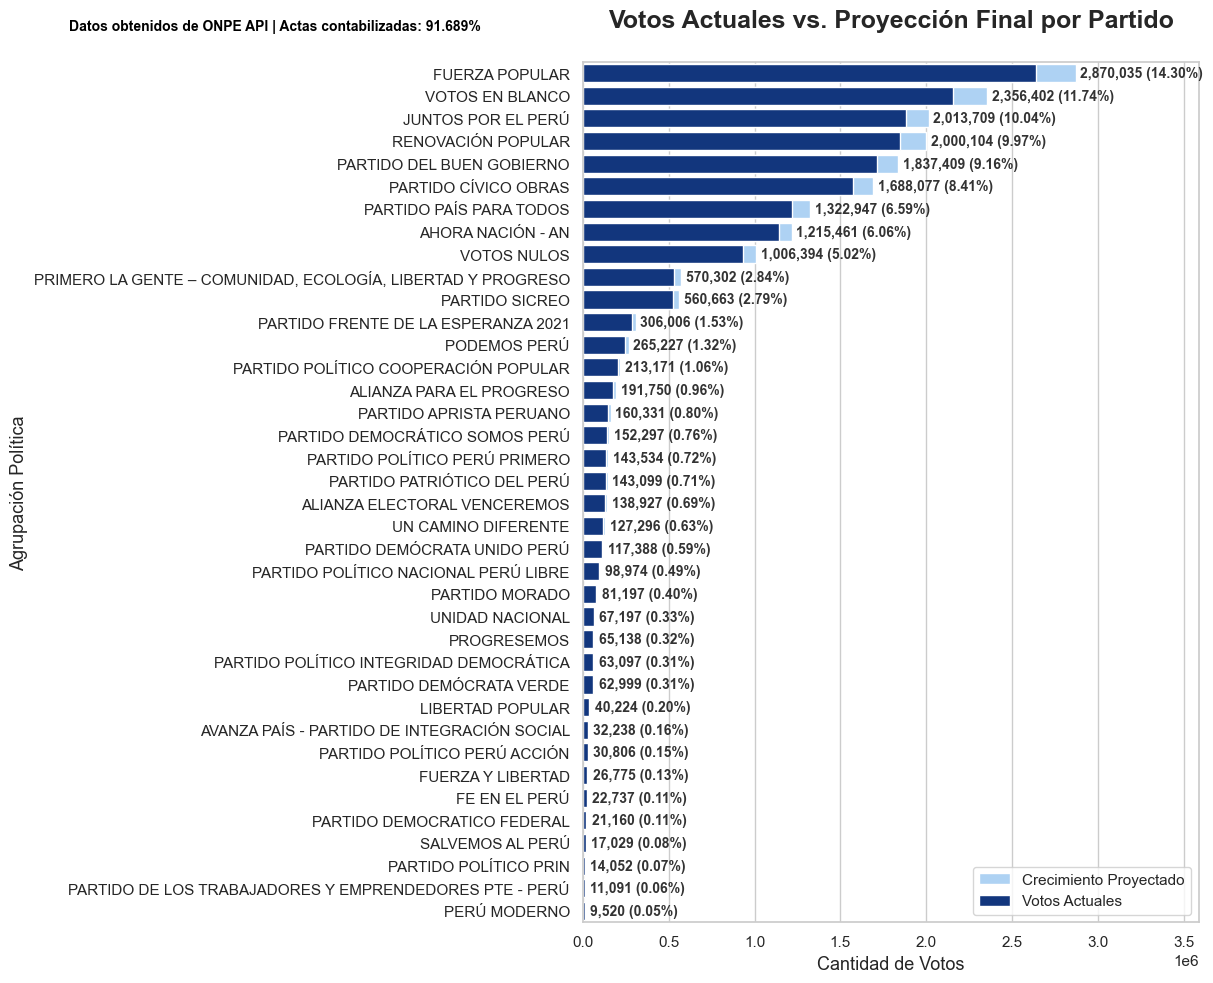

In [64]:
plot_proyeccion()

count=2102
count=2103
count=2104
count=2105
count=2106
count=2107
count=2108
count=2109
count=2110
count=2111
count=2112
count=2113
count=2114
count=2115
count=2116
count=2117
count=2118
count=2119
count=2120
count=2121
count=2122
count=2123
count=2124
count=2125
count=2126
count=2127
count=2128
count=2129
count=2130
count=2131
count=2132
count=2133
count=2134
count=2135count=2135
count=2136
count=2137
count=2138

count=2140
count=2141
count=2142
count=2143
count=2144
count=2145
count=2146
count=2147
count=2148
count=2149
count=2150
count=2151
count=2152
count=2153
count=2154
count=2155
count=2156
count=2157
count=2158
count=2159
count=2160
count=2161
count=2162
count=2163
count=2164
count=2165
count=2166
count=2167
count=2168
count=2169
count=2170
count=2171
count=2172
count=2173
count=2174
count=2175
count=2176
count=2177
count=2178
count=2179
count=2180
count=2181
count=2182
count=2183
count=2184count=2184

count=2186
count=2187
count=2188
count=2189
count=2190
count=2191
count=2192

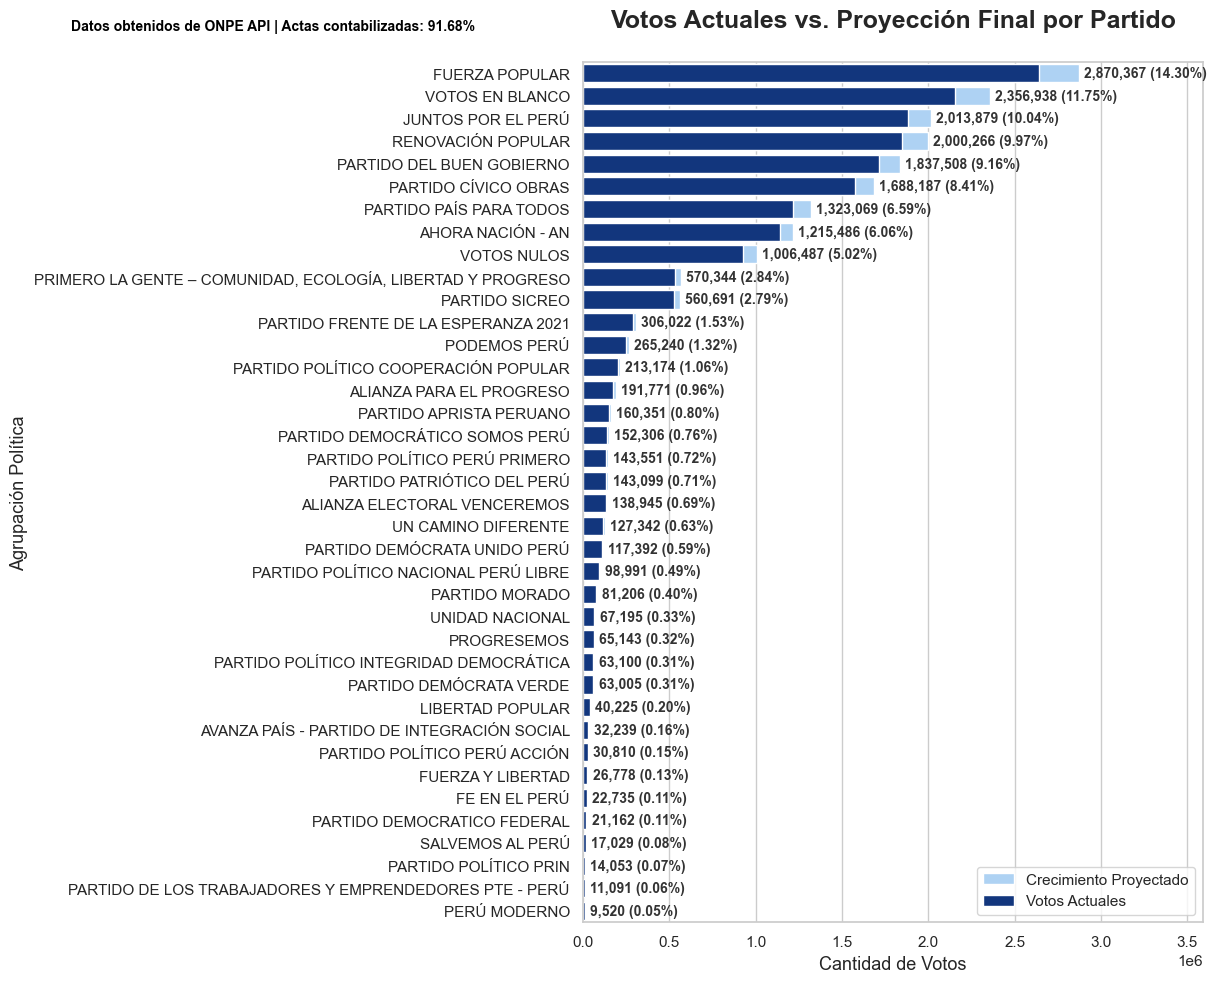

In [57]:
plot_proyeccion()

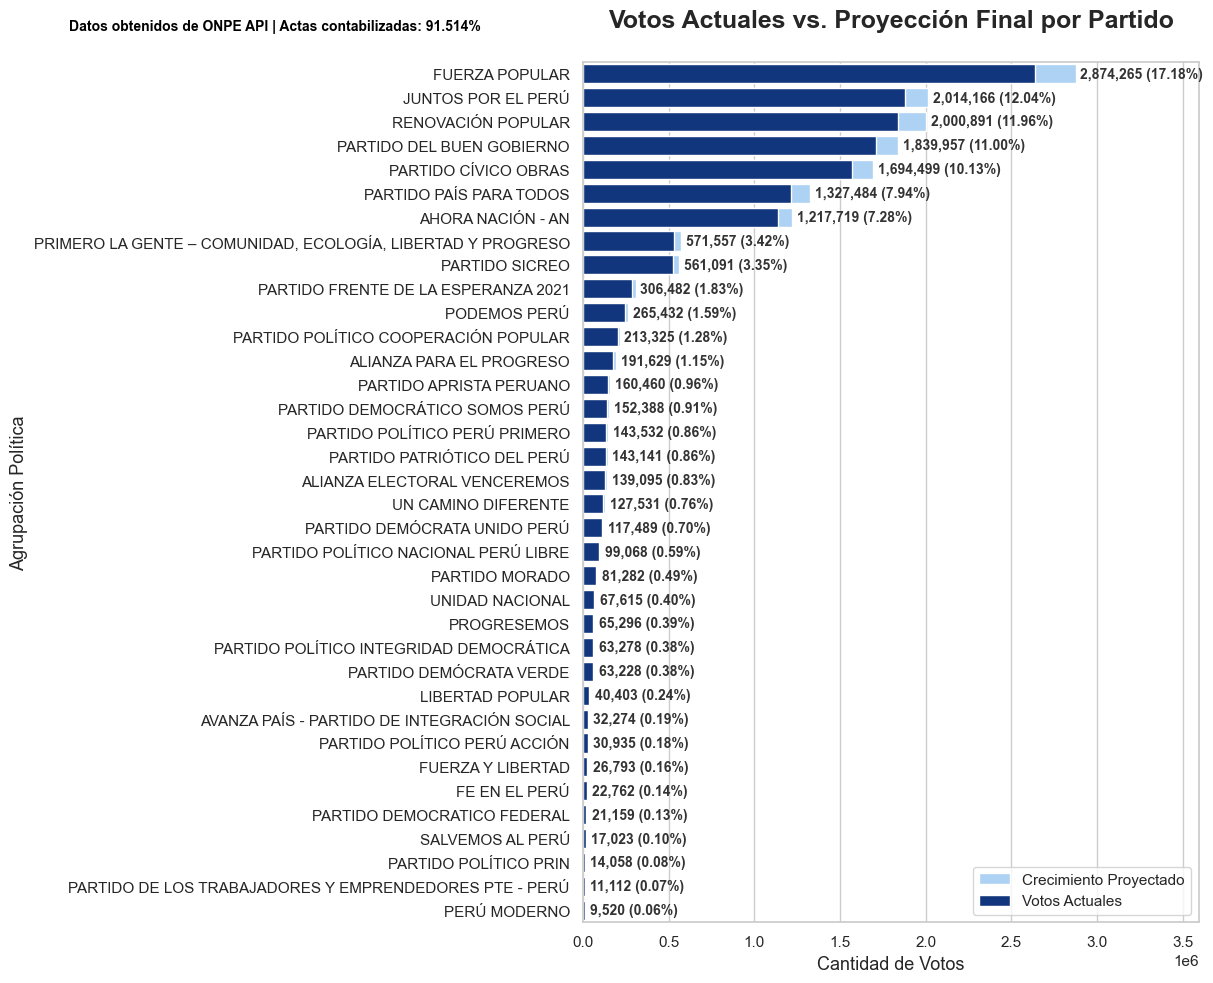